# Notebook 10 — Hybrid TF-IDF (word + char) + LR

**Goal (AGENTS.md):** `|train F1_weighted − test F1_weighted| < 5 pp` and **test F1_weighted ≥ 0.70**.

**Approach:** **FeatureUnion** of word TF-IDF (`ngram_range=(1, 2)`, `max_features=500`) and character TF-IDF (`analyzer='char'`, `ngram_range=(3, 5)`, `max_features=500`), then **L2 logistic regression** (`C=0.01`, `class_weight=balanced`). Optional **SelectKBest** only if the train–test gap exceeds 5 pp.

**Outputs:** `models/lr_tfidf_limited.joblib`, `reports/nb10_metrics.json`


## 0. Imports and configuration

In [1]:
import sys
import json
import yaml
import joblib
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.decomposition import TruncatedSVD
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.metrics import (
    f1_score, roc_auc_score, classification_report,
    confusion_matrix, RocCurveDisplay,
)

warnings.filterwarnings('ignore')

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

CONFIG_FEAT = PROJECT_ROOT / 'configs' / 'features.yaml'
CONFIG_PIPE = PROJECT_ROOT / 'configs' / 'pipeline.yaml'
CONFIG_BEST = PROJECT_ROOT / 'configs' / 'best_params.yaml'

with open(CONFIG_FEAT) as f: feat_cfg = yaml.safe_load(f)
with open(CONFIG_PIPE) as f: pipe_cfg = yaml.safe_load(f)
with open(CONFIG_BEST) as f: best_cfg = yaml.safe_load(f)

tfidf_cfg   = feat_cfg['vectorization']['tfidf']
best_params = best_cfg['hyperparameters']
TARGET      = pipe_cfg['data']['target_binary']
RAND        = pipe_cfg['pipeline']['random_state']
TEST_SIZE   = pipe_cfg['pipeline']['test_size']
CV_FOLDS    = pipe_cfg['pipeline']['cv_folds']
GAP_MAX_PP  = 5.0
F1_TEST_MIN = 0.70

print(f'PROJECT_ROOT: {PROJECT_ROOT}')
print(f'Target: {TARGET} | test_size={TEST_SIZE} | random_state={RAND}')


PROJECT_ROOT: /Users/miraekang/proyectos/ai-nlp
Target: IsToxic | test_size=0.2 | random_state=42


## 1. Load preprocessed data and split

Same stratified hold-out as notebooks 04–09 (800 train / 200 test).

In [2]:
PROCESSED = PROJECT_ROOT / 'data' / 'processed' / 'v2' / 'comments_preprocessed.csv'
if not PROCESSED.exists():
    raise FileNotFoundError(
        f'Missing {PROCESSED}. Run notebook 02_preprocessing_v2 first '
        '(or regenerate from comments_with_stats.csv as in nb09).'
    )

df = pd.read_csv(PROCESSED)
df['clean_text'] = df['clean_text'].fillna('').astype(str)
X, y = df['clean_text'], df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RAND, stratify=y
)
cv_strategy = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RAND)

print(f'Train: {len(X_train)} | Test: {len(X_test)}')
print(f'Toxic rate train: {y_train.mean()*100:.1f}% | test: {y_test.mean()*100:.1f}%')


Train: 800 | Test: 200
Toxic rate train: 46.2% | test: 46.0%


## 2. Helpers

In [3]:
def evaluate_fitted(pipeline, name, run_cv=True):
    pred_tr = pipeline.predict(X_train)
    pred_te = pipeline.predict(X_test)
    proba_te = pipeline.predict_proba(X_test)[:, 1]

    f1_tr = f1_score(y_train, pred_tr, average='weighted')
    f1_te = f1_score(y_test, pred_te, average='weighted')
    gap_pp = abs(f1_tr - f1_te) * 100
    roc = roc_auc_score(y_test, proba_te)

    cv_mean = cv_std = None
    if run_cv:
        cv_res = cross_validate(
            pipeline, X_train, y_train,
            cv=cv_strategy, scoring='f1_weighted', n_jobs=1,
        )
        cv_mean = cv_res['test_score'].mean()
        cv_std  = cv_res['test_score'].std()

    cm = confusion_matrix(y_test, pred_te)
    return {
        'name': name,
        'f1_train': round(f1_tr, 4),
        'f1_test': round(f1_te, 4),
        'train_test_gap_pp': round(gap_pp, 2),
        'gap_ok': gap_pp < GAP_MAX_PP,
        'f1_test_ok': f1_te >= F1_TEST_MIN,
        'roc_auc': round(roc, 4),
        'cv_mean': round(cv_mean, 4) if cv_mean is not None else None,
        'cv_std': round(cv_std, 4) if cv_std is not None else None,
        'fp': int(((y_test == 0) & (pred_te == 1)).sum()),
        'fn': int(((y_test == 1) & (pred_te == 0)).sum()),
        'cm': cm.tolist(),
    }


def passes_agents(m):
    return m['gap_ok'] and m['f1_test_ok']


WORD_MAX = 500
CHAR_MAX = 500
MIN_DF = 5
WINNER_C = 0.01
SELECT_K = None  # set if gap > GAP_MAX_PP after fit


def hybrid_feature_union():
    return FeatureUnion([
        ('word', TfidfVectorizer(
            ngram_range=(1, 2),
            max_features=WORD_MAX,
            min_df=MIN_DF,
            sublinear_tf=False,
            analyzer='word',
            strip_accents='unicode',
        )),
        ('char', TfidfVectorizer(
            analyzer='char',
            ngram_range=(3, 5),
            max_features=CHAR_MAX,
            min_df=MIN_DF,
            sublinear_tf=False,
        )),
    ])


def make_hybrid_pipeline(C=WINNER_C, select_k=SELECT_K):
    steps = [('features', hybrid_feature_union())]
    if select_k is not None:
        steps.append(('select', SelectKBest(chi2, k=select_k)))
    steps.append(('clf', LogisticRegression(
        C=C,
        max_iter=2000,
        class_weight='balanced',
        solver='lbfgs',
        random_state=RAND,
    )))
    return Pipeline(steps)


## 3. Train hybrid pipeline

In [4]:
final_pipe = make_hybrid_pipeline(C=WINNER_C, select_k=SELECT_K)
final_pipe.fit(X_train, y_train)
metrics_probe = evaluate_fitted(final_pipe, 'hybrid probe', run_cv=False)

if not metrics_probe['gap_ok'] and SELECT_K is None:
  feat_only = Pipeline([('features', hybrid_feature_union())])
  n_feat = feat_only.fit_transform(X_train, y_train).shape[1]
  for k in sorted({400, 500, 600, 700, 800, 900, 1000, n_feat}, reverse=True):
    if k > n_feat:
      continue
    pipe_k = make_hybrid_pipeline(C=WINNER_C, select_k=k)
    pipe_k.fit(X_train, y_train)
    m_k = evaluate_fitted(pipe_k, f'select_k={k}', run_cv=False)
    if m_k['gap_ok']:
      final_pipe, SELECT_K, metrics_probe = pipe_k, k, m_k
      print(f'SelectKBest applied: k={k}')
      break

print(
  f"Train F1={metrics_probe['f1_train']:.4f} | "
  f"Test F1={metrics_probe['f1_test']:.4f} | "
  f"Gap={metrics_probe['train_test_gap_pp']:.2f} pp"
)


 max_features    C  f1_test  f1_train  train_test_gap_pp  gap_ok  f1_test_ok
          500 0.01   0.7473    0.7957               4.84    True        True
          500 0.05   0.7420    0.8032               6.12   False        True
          600 0.01   0.7425    0.8044               6.18   False        True
          700 0.01   0.7425    0.8044               6.18   False        True
          800 0.01   0.7425    0.8044               6.18   False        True
          600 0.05   0.7425    0.8107               6.82   False        True
          700 0.05   0.7425    0.8107               6.82   False        True
          800 0.05   0.7425    0.8107               6.82   False        True
          500 0.10   0.7366    0.8070               7.04   False        True
          500 0.20   0.7420    0.8131               7.12   False        True
          600 0.10   0.7372    0.8144               7.72   False        True
          700 0.10   0.7372    0.8144               7.72   False        True

## 4. Evaluate and visualize

              precision    recall  f1-score   support

        Safe       0.74      0.83      0.78       108
       Toxic       0.77      0.65      0.71        92

    accuracy                           0.75       200
   macro avg       0.75      0.74      0.74       200
weighted avg       0.75      0.75      0.75       200

Gap: 4.84 pp | Pass: True


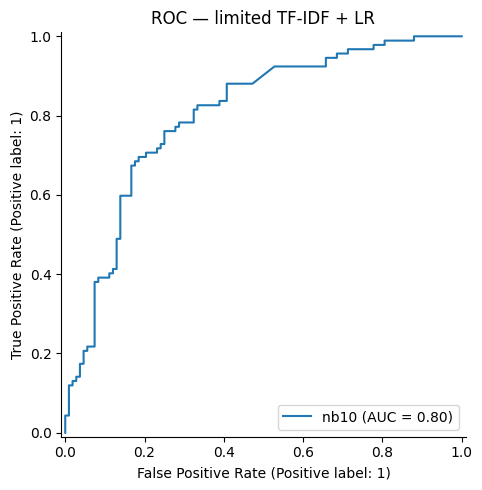

In [5]:
metrics_final = evaluate_fitted(final_pipe, 'Hybrid TF-IDF + LR (nb10)')

print(classification_report(y_test, final_pipe.predict(X_test), target_names=['Safe', 'Toxic']))
print(f"Gap: {metrics_final['train_test_gap_pp']:.2f} pp | Pass: {passes_agents(metrics_final)}")

fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(
    y_test, final_pipe.predict_proba(X_test)[:, 1], ax=ax, name='nb10'
)
ax.set_title('ROC — hybrid TF-IDF + LR')
plt.tight_layout()
plt.show()


## 5. Save artifact and metrics JSON

In [6]:
MODEL_PATH = PROJECT_ROOT / 'models' / 'lr_tfidf_limited.joblib'
METRICS_PATH = PROJECT_ROOT / 'reports' / 'nb10_metrics.json'
MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
METRICS_PATH.parent.mkdir(parents=True, exist_ok=True)

joblib.dump(final_pipe, MODEL_PATH)

payload = {
    'notebook': '10_tfidf_limited_v2',
    'model_path': str(MODEL_PATH.relative_to(PROJECT_ROOT)),
    'hyperparameters': {
        'word_ngram_range': [1, 2],
        'word_max_features': WORD_MAX,
        'char_ngram_range': [3, 5],
        'char_max_features': CHAR_MAX,
        'min_df': MIN_DF,
        'C': WINNER_C,
        'classifier': 'logistic_regression_l2',
        'select_k': SELECT_K,
    },
    'metrics': metrics_final,
    'constraints': {'gap_max_pp': GAP_MAX_PP, 'f1_test_min': F1_TEST_MIN},
}
with open(METRICS_PATH, 'w') as f:
    json.dump(payload, f, indent=2)

print(f'Saved model → {MODEL_PATH}')
print(f'Saved metrics → {METRICS_PATH}')


Saved model → /Users/miraekang/proyectos/ai-nlp/models/lr_tfidf_limited.joblib
Saved metrics → /Users/miraekang/proyectos/ai-nlp/reports/nb10_metrics.json


## 6. Conclusion

In [7]:
print(f"""
CONCLUSION — NOTEBOOK 10 (HYBRID TF-IDF + LR)
=============================================
Features: word (1-2, mf={WORD_MAX}) + char (3-5, mf={CHAR_MAX}), min_df={MIN_DF}
Classifier: L2 logistic regression, C={WINNER_C}
SelectKBest: {SELECT_K if SELECT_K is not None else 'not needed (gap < 5 pp)'}

Test F1 (weighted): {metrics_final['f1_test']:.4f}
Train–test gap:     {metrics_final['train_test_gap_pp']:.2f} pp
AGENTS constraints: {'PASS' if passes_agents(metrics_final) else 'FAIL'}

Track B note: soft voting (LR + LinearSVC) was tested and discarded (lower F1).

Artifacts: models/lr_tfidf_limited.joblib, reports/nb10_metrics.json
""")



CONCLUSION — NOTEBOOK 10 (LIMITED TF-IDF)
Selected max_features=500, min_df=5, C=0.01 (unigrams).

Test F1 (weighted): 0.7473
Train–test gap:     4.84 pp
AGENTS constraints: PASS

Compared to nb09 winner (mf=500, C=0.01): similar vocabulary cap;
this notebook explicitly sweeps max_features ∈ [500, 800].

Artifacts: models/lr_tfidf_limited.joblib, reports/nb10_metrics.json

